<a href="https://colab.research.google.com/github/SiramGanesh/ML-DEEP-LEARNING-QUANTUM-ML/blob/main/CNN%20AND%20QCNN%20CIC%20DATASET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to your folder
folder_path = '/content/drive/My Drive/archive'

# Check if the folder exists
if not os.path.exists(folder_path):
    print(f"Error: Folder '{folder_path}' not found. Please check the folder name and path in your Google Drive.")
else:
    print(f"Contents of '{folder_path}':")
    files = os.listdir(folder_path)
    if files:
        for f in files:
            print(f)

        # Assuming the data is in a CSV file, let's try to find and load the first one
        csv_files = [f for f in files if f.endswith('.csv')]
        if csv_files:
            file_to_load = os.path.join(folder_path, csv_files[0])
            print(f"\nAttempting to load '{file_to_load}' into DataFrame 'df'...")
            try:
                df = pd.read_csv(file_to_load)
                print("DataFrame 'df' loaded successfully. First 5 rows:")
                print(df.head())
            except Exception as e:
                print(f"Error loading CSV file: {e}")
        else:
            print("No CSV files found in the folder. Please specify the correct file type or name.")
    else:
        print("The folder is empty.")


Mounted at /content/drive
Contents of '/content/drive/My Drive/archive':
part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00006-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00005-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00007-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00008-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00011-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00010-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00009-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00013-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00012-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00014-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00015-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00017-363d

In [9]:
dfs = []
SAMPLES_PER_FILE = 3200  # Adjust as needed

# Ensure 'files' is sorted for consistent processing if order matters
# files.sort() # Uncomment if you need a specific order

print(f"Processing {len(csv_files)} CSV files...")

for i, file in enumerate(csv_files):
    full_file_path = os.path.join(folder_path, file)
    try:
        temp = pd.read_csv(full_file_path)

        sample_size = min(SAMPLES_PER_FILE, len(temp))

        temp_sampled = temp.sample(
            n=sample_size,
            random_state=42
        )

        dfs.append(temp_sampled)

        if (i + 1) % 20 == 0:
            print(f"Processed {i+1}/{len(csv_files)} files")
    except Exception as e:
        print(f"Error processing file {full_file_path}: {e}")

df = pd.concat(dfs, ignore_index=True)

print("\nFinal DataFrame 'df' created by concatenating samples.")
print("Final Shape:", df.shape)

print("\nNumber of Classes (unique labels):")
print(df['label'].nunique())

print("\nTop 10 Labels (value counts):")
print(df['label'].value_counts().head(10))

Processing 169 CSV files...
Processed 20/169 files
Processed 40/169 files
Processed 60/169 files
Processed 80/169 files
Processed 100/169 files
Processed 120/169 files
Processed 140/169 files
Processed 160/169 files

Final DataFrame 'df' created by concatenating samples.
Final Shape: (540800, 47)

Number of Classes (unique labels):
34

Top 10 Labels (value counts):
label
DDoS-ICMP_Flood            83110
DDoS-UDP_Flood             62281
DDoS-TCP_Flood             52262
DDoS-PSHACK_Flood          47914
DDoS-SYN_Flood             47207
DDoS-RSTFINFlood           46826
DDoS-SynonymousIP_Flood    41616
DoS-UDP_Flood              38651
DoS-TCP_Flood              30988
DoS-SYN_Flood              23293
Name: count, dtype: int64


In [10]:
print("Total Classes:", df['label'].nunique())

print("\nClasses:")
print(df['label'].value_counts())


Total Classes: 34

Classes:
label
DDoS-ICMP_Flood            83110
DDoS-UDP_Flood             62281
DDoS-TCP_Flood             52262
DDoS-PSHACK_Flood          47914
DDoS-SYN_Flood             47207
DDoS-RSTFINFlood           46826
DDoS-SynonymousIP_Flood    41616
DoS-UDP_Flood              38651
DoS-TCP_Flood              30988
DoS-SYN_Flood              23293
BenignTraffic              12576
Mirai-greeth_flood         11567
Mirai-udpplain             10229
Mirai-greip_flood           8737
DDoS-ICMP_Fragmentation     5249
MITM-ArpSpoofing            3637
DDoS-UDP_Fragmentation      3327
DDoS-ACK_Fragmentation      3303
DNS_Spoofing                2067
Recon-HostDiscovery         1558
Recon-OSScan                1170
Recon-PortScan               918
DoS-HTTP_Flood               845
VulnerabilityScan            441
DDoS-HTTP_Flood              334
DDoS-SlowLoris               247
DictionaryBruteForce         162
CommandInjection              60
BrowserHijacking              59
SqlInject

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["multi_label"] = le.fit_transform(df["label"])

print("Number of classes:", df["multi_label"].nunique())

print("\nEncoded Classes:")

for i, cls in enumerate(le.classes_):
    print(i, "->", cls)

Number of classes: 34

Encoded Classes:
0 -> Backdoor_Malware
1 -> BenignTraffic
2 -> BrowserHijacking
3 -> CommandInjection
4 -> DDoS-ACK_Fragmentation
5 -> DDoS-HTTP_Flood
6 -> DDoS-ICMP_Flood
7 -> DDoS-ICMP_Fragmentation
8 -> DDoS-PSHACK_Flood
9 -> DDoS-RSTFINFlood
10 -> DDoS-SYN_Flood
11 -> DDoS-SlowLoris
12 -> DDoS-SynonymousIP_Flood
13 -> DDoS-TCP_Flood
14 -> DDoS-UDP_Flood
15 -> DDoS-UDP_Fragmentation
16 -> DNS_Spoofing
17 -> DictionaryBruteForce
18 -> DoS-HTTP_Flood
19 -> DoS-SYN_Flood
20 -> DoS-TCP_Flood
21 -> DoS-UDP_Flood
22 -> MITM-ArpSpoofing
23 -> Mirai-greeth_flood
24 -> Mirai-greip_flood
25 -> Mirai-udpplain
26 -> Recon-HostDiscovery
27 -> Recon-OSScan
28 -> Recon-PingSweep
29 -> Recon-PortScan
30 -> SqlInjection
31 -> Uploading_Attack
32 -> VulnerabilityScan
33 -> XSS


In [12]:
import numpy as np

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nInfinite Values:")
print(np.isinf(df.select_dtypes(include=[np.number])).sum().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (540800, 48)

Missing Values:
0

Infinite Values:
0

Data Types:
flow_duration      float64
Header_Length      float64
Protocol Type      float64
Duration           float64
Rate               float64
Srate              float64
Drate              float64
fin_flag_number    float64
syn_flag_number    float64
rst_flag_number    float64
psh_flag_number    float64
ack_flag_number    float64
ece_flag_number    float64
cwr_flag_number    float64
ack_count          float64
syn_count          float64
fin_count          float64
urg_count          float64
rst_count          float64
HTTP               float64
HTTPS              float64
DNS                float64
Telnet             float64
SMTP               float64
SSH                float64
IRC                float64
TCP                float64
UDP                float64
DHCP               float64
ARP                float64
ICMP               float64
IPv                float64
LLC                float64
Tot sum            float64
Mi

In [13]:
feature_cols = [col for col in df.columns
                if col not in ["label",
                               "multi_label"]]

print("Number of Features:", len(feature_cols))

print(feature_cols)

Number of Features: 46
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight']


In [14]:
X = df[feature_cols].copy()
y_multi = df["multi_label"].copy()

print("X Shape:", X.shape)
print("Multiclass Labels:", y_multi.shape)

X Shape: (540800, 46)
Multiclass Labels: (540800,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_multi,
    test_size=0.30,
    random_state=42,
    stratify=y_multi
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nClasses in Train:", y_train.nunique())
print("Classes in Test:", y_test.nunique())

Train: (378560, 46)
Test: (162240, 46)

Classes in Train: 34
Classes in Test: 34


In [16]:
!pip install qiskit qiskit-machine-learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.9 MB/s eta 0:00:00


In [17]:
!pip install qiskit-algorithms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 6.8 MB/s eta 0:00:00


In [18]:
!pip install tensorflow-quantum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 597.5/597.5 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.7/323.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.1/105.1 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.6/615.6 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 60.4 MB/s eta 0:00:00
  Attempting uninstall: contourpy
    Found existing installation: contourpy 1.3.3
    Uninstalling contourpy-1.3.3:
      Successfully uninstalled contourpy-1.3.3
  Attempting uninstall: tensorboard
    Found exis

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(378560, 46)
(162240, 46)


CNN model

In [54]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("Number of weights:", len(class_weights))

print(class_weights)

Number of weights: 34
tensor([4.2824e+02, 1.2648e+00, 2.7156e+02, 2.6510e+02, 4.8158e+00, 4.7582e+01,
        1.9138e-01, 3.0305e+00, 3.3197e-01, 3.3968e-01, 3.3694e-01, 6.4359e+01,
        3.8221e-01, 3.0435e-01, 2.5539e-01, 4.7806e+00, 7.6946e+00, 9.8532e+01,
        1.8839e+01, 6.8287e-01, 5.1328e-01, 4.1152e-01, 4.3732e+00, 1.3751e+00,
        1.8205e+00, 1.5550e+00, 1.0205e+01, 1.3595e+01, 7.4227e+02, 1.7316e+01,
        3.0928e+02, 1.1134e+03, 3.6033e+01, 3.8394e+02])


In [87]:
import torch
from torch.utils.data import Dataset

class CICDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y, # Removed .values as y is already a NumPy array
            dtype=torch.long
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [57]:
train_dataset = CICDataset(
    X_train,
    y_train
)

test_dataset = CICDataset(
    X_test,
    y_test
)

print(len(train_dataset))
print(len(test_dataset))

378560
162240


In [58]:
from torch.utils.data import DataLoader

BATCH_SIZE = 1024

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 370
Test batches: 159


In [59]:
import torch
import torch.nn as nn

class CNN1D(nn.Module):
    def __init__(self, num_features=46, num_classes=34):
        super().__init__()
        # Input shape: (Batch, 1, 46)
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            # Reduces the feature dimension to 1
            nn.AdaptiveMaxPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.2), # Added dropout to prevent overfitting
            nn.Linear(64, num_classes) # Changed to output 34 classes
        )

    def forward(self, x):
        # x input shape: (batch, 46)
        x = x.unsqueeze(1) # Transform to (batch, 1, 46)
        x = self.conv(x)
        x = x.view(x.size(0), -1) # Flatten to (batch, 32)
        return self.fc(x) # Returns logits

In [60]:
model = CNN1D(
    num_features=46,
    num_classes=34
)

In [61]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

In [62]:
import torch

x = torch.randn(10, 5)

print(x)

tensor([[ 0.7659,  1.0988,  0.5569,  0.1733, -1.7346],
        [-0.4711, -0.7225,  0.5766, -0.3629,  0.5097],
        [ 0.7192, -0.6047,  0.8302,  1.4362, -0.2934],
        [-1.1009, -0.7832, -1.0739,  0.8809,  0.3108],
        [-0.9752,  1.1693,  1.4669,  0.0759,  0.4556],
        [-0.0034, -0.3165, -0.4172,  0.5455, -0.2394],
        [ 0.6676, -0.4629, -0.6400,  0.8414,  0.7145],
        [ 2.3051, -0.6709,  0.7317, -0.8129, -0.3467],
        [ 0.1681, -0.0252, -2.1488,  0.3879,  0.7758],
        [-0.2144, -0.1229, -0.4203,  1.3678, -1.1219]])


In [63]:
X_batch, y_batch = next(iter(train_loader))

with torch.no_grad():
    outputs = model(X_batch)

print(outputs.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([1024, 34])


In [66]:
import torch
from sklearn.metrics import accuracy_score
import time # Added import time

EPOCHS = 10
#Record the start time for training
cnn_start_time = time.time()
best_val_loss = float("inf")

for epoch in range(EPOCHS):

    # ------------------
    # TRAIN
    # ------------------
    model.train()

    train_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ------------------
    # test
    # ------------------
    model.eval()

    test_loss = 0 # Initialize test_loss

    preds = []
    actuals = []

    with torch.inference_mode():

        for X_batch, y_batch in test_loader:

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            test_loss += loss.item()

            pred = torch.argmax(
                outputs,
                dim=1
            )

            preds.extend(
                pred.cpu().numpy()
            )

            actuals.extend(
                y_batch.cpu().numpy()
            )

    test_loss /= len(test_loader) # Changed from val_loader to test_loader

    test_acc = accuracy_score(
        actuals,
        preds
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | " # Changed from val_loss to test_loss
        f"Test Acc: {test_acc:.4f}" # Changed from val_acc to test_acc
    )
# Record the end time for training
cnn_end_time = time.time()

# Calculate the elapsed time for training
cnn_training_time = cnn_end_time - cnn_start_time

print("Time taken for CNN model training:", cnn_training_time, "seconds")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 | Train Loss: 2.1677 | Test Loss: 2.0049 | Test Acc: 0.5019


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 2/10 | Train Loss: 2.0039 | Test Loss: 1.9014 | Test Acc: 0.5149


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Epoch 8/10 | Train Loss: 1.6023 | Test Loss: 1.5494 | Test Acc: 0.5289


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 9/10 | Train Loss: 1.5814 | Test Loss: 1.5437 | Test Acc: 0.5401


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 10/10 | Train Loss: 1.5690 | Test Loss: 1.5262 | Test Acc: 0.5423
Time taken for CNN model training: 295.20802998542786 seconds


In [67]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

start_time = time.time()

model.eval()

preds = []
actuals = []

with torch.inference_mode():

    for X_batch, y_batch in test_loader:

        outputs = model(X_batch)

        pred = torch.argmax(outputs, dim=1)

        preds.extend(pred.cpu().numpy())
        actuals.extend(y_batch.numpy())

print(
    classification_report(
        actuals,
        preds,
        digits=4
    )
)
# Record the end time for training
end_time = time.time()

# Calculate the elapsed time for training
training_time = end_time - start_time

print("Time taken for training:", training_time, "seconds")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

           0     0.0089    0.3636    0.0174        11
           1     0.8008    0.3729    0.5089      3773
           2     0.0000    0.0000    0.0000        18
           3     0.0049    0.0556    0.0090        18
           4     0.9767    0.7185    0.8279       991
           5     0.1736    0.7500    0.2820       100
           6     0.9991    0.9985    0.9988     24933
           7     0.9910    0.9733    0.9821      1575
           8     0.0000    0.0000    0.0000     14374
           9     1.0000    0.9891    0.9945     14048
          10     0.3154    0.0211    0.0396     14162
          11     0.0714    0.1486    0.0965        74
          12     0.1198    0.0140    0.0251     12485
          13     0.2258    0.8605    0.3578     15679
          14     0.7091    0.8978    0.7924     18684
          15     0.9732    0.9830    0.9781       998
          16     0.2642    0.2097    0.2338       620
          17     0.0612    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [68]:
import pandas as pd

multi_accuracy = accuracy_score(
    actuals,
    preds
)

multi_precision = precision_score(
    actuals,
    preds,
    average='weighted'
)

multi_recall = recall_score(
    actuals,
    preds,
    average='weighted'
)

multi_f1 = f1_score(
    actuals,
    preds,
    average='weighted'
)

multi_macro_f1 = f1_score(
    actuals,
    preds,
    average='macro'
)

multi_df = pd.DataFrame({
    "Model":["Transformer Multiclass"],
    "Classes":[34],
    "Accuracy (%)":[multi_accuracy*100],
    "Precision (%)":[multi_precision*100],
    "Recall (%)":[multi_recall*100],
    "Weighted F1 (%)":[multi_f1*100],
    "Macro F1 (%)":[multi_macro_f1*100]
})

multi_df.round(2)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Classes,Accuracy (%),Precision (%),Recall (%),Weighted F1 (%),Macro F1 (%)
0,Transformer Multiclass,34,54.23,52.62,54.23,49.14,34.1


CNN 34 classes with top 20 features

In [72]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report
import time

# 1. Train a RandomForestClassifier to get feature importances
print("Training RandomForestClassifier for feature importance...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2. Get feature importances and select top 20
feature_importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
top_20_features = feature_importances.nlargest(20).index.tolist()

print(f"\nTop 20 features selected: {top_20_features}")

# 3. Filter X_train and X_test to include only these top 20 features
X_train_top20 = X[top_20_features].iloc[y_train.index]
X_test_top20 = X[top_20_features].iloc[y_test.index]

# Scale the data again with only the top 20 features
scaler_top20 = MinMaxScaler()
X_train_top20_scaled = scaler_top20.fit_transform(X_train_top20)
X_test_top20_scaled = scaler_top20.transform(X_test_top20)

print(f"\nShape of X_train with top 20 features: {X_train_top20_scaled.shape}")
print(f"Shape of X_test with top 20 features: {X_test_top20_scaled.shape}")

# 4. Re-create CICDataset, DataLoader with new feature set
train_dataset_top20 = CICDataset(
    X_train_top20_scaled,
    y_train
)

test_dataset_top20 = CICDataset(
    X_test_top20_scaled,
    y_test
)

train_loader_top20 = DataLoader(
    train_dataset_top20,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader_top20 = DataLoader(
    test_dataset_top20,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# 5. Define and train a new CNN model with num_features=20
NUM_FEATURES_CNN_TOP20 = 20
NUM_CLASSES = 34 # Based on the earlier 'multi_label' encoding

class CNN1D_Top20(nn.Module):
    def __init__(self, num_features=20, num_classes=34):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model_cnn_top20 = CNN1D_Top20(
    num_features=NUM_FEATURES_CNN_TOP20,
    num_classes=NUM_CLASSES
)

criterion_cnn_top20 = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer_cnn_top20 = torch.optim.AdamW(
    model_cnn_top20.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

print("\nStarting CNN model training with top 20 features...")
EPOCHS = 10
cnn_top20_start_time = time.time()
best_val_loss = float("inf")

for epoch in range(EPOCHS):

    # TRAIN
    model_cnn_top20.train()
    train_loss = 0
    for X_batch, y_batch in train_loader_top20:
        optimizer_cnn_top20.zero_grad()
        outputs = model_cnn_top20(X_batch)
        loss = criterion_cnn_top20(outputs, y_batch)
        loss.backward()
        optimizer_cnn_top20.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_top20)

    # EVALUATE
    model_cnn_top20.eval()
    test_loss = 0
    preds = []
    actuals = []
    with torch.inference_mode():
        for X_batch, y_batch in test_loader_top20:
            outputs = model_cnn_top20(X_batch)
            loss = criterion_cnn_top20(outputs, y_batch)
            test_loss += loss.item()
            pred = torch.argmax(outputs, dim=1)
            preds.extend(pred.cpu().numpy())
            actuals.extend(y_batch.cpu().numpy())
    test_loss /= len(test_loader_top20)

    test_acc = accuracy_score(actuals, preds)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

cnn_top20_end_time = time.time()
cnn_top20_training_time = cnn_top20_end_time - cnn_top20_start_time
print(f"\nTime taken for CNN model training with top 20 features: {cnn_top20_training_time:.2f} seconds")

print("\nClassification Report for CNN with Top 20 Features:")
print(classification_report(actuals, preds, digits=4))


Training RandomForestClassifier for feature importance...

Top 20 features selected: ['IAT', 'Magnitue', 'syn_count', 'Min', 'Protocol Type', 'syn_flag_number', 'AVG', 'Header_Length', 'Tot size', 'psh_flag_number', 'Tot sum', 'ack_count', 'fin_flag_number', 'Max', 'flow_duration', 'UDP', 'urg_count', 'rst_count', 'Rate', 'ICMP']

Shape of X_train with top 20 features: (378560, 20)
Shape of X_test with top 20 features: (162240, 20)

Starting CNN model training with top 20 features...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 | Train Loss: 3.1244 | Test Loss: 2.7175 | Test Acc: 0.3429


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 2/10 | Train Loss: 2.4103 | Test Loss: 2.0501 | Test Acc: 0.5554


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 9/10 | Train Loss: 1.4775 | Test Loss: 1.4098 | Test Acc: 0.7604


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 10/10 | Train Loss: 1.4548 | Test Loss: 1.3724 | Test Acc: 0.7079

Time taken for CNN model training with top 20 features: 184.99 seconds

Classification Report for CNN with Top 20 Features:
              precision    recall  f1-score   support

           0     0.0056    0.4545    0.0110        11
           1     0.7819    0.4143    0.5416      3773
           2     0.0000    0.0000    0.0000        18
           3     0.0000    0.0000    0.0000        18
           4     0.9220    0.9667    0.9438       991
           5     0.1583    0.6000    0.2505       100
           6     0.9987    0.9955    0.9971     24933
           7     0.9576    0.9740    0.9657      1575
           8     0.9944    0.9809    0.9876     14374
           9     0.9991    0.9979    0.9985     14048
          10     0.5896    0.9735    0.7344     14162
          11     0.0163    0.1081    0.0283        74
          12     0.6314    0.4579    0.5309     12485
          13     0.4711    0.0223    0.0426   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


CNN model with top 10 features

In [46]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("Number of weights:", len(class_weights))
print(class_weights)

Number of weights: 34
tensor([4.2824e+02, 1.2648e+00, 2.7156e+02, 2.6510e+02, 4.8158e+00, 4.7582e+01,
        1.9138e-01, 3.0305e+00, 3.3197e-01, 3.3968e-01, 3.3694e-01, 6.4359e+01,
        3.8221e-01, 3.0435e-01, 2.5539e-01, 4.7806e+00, 7.6946e+00, 9.8532e+01,
        1.8839e+01, 6.8287e-01, 5.1328e-01, 4.1152e-01, 4.3732e+00, 1.3751e+00,
        1.8205e+00, 1.5550e+00, 1.0205e+01, 1.3595e+01, 7.4227e+02, 1.7316e+01,
        3.0928e+02, 1.1134e+03, 3.6033e+01, 3.8394e+02])


In [73]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report
import time

# 1. Train a RandomForestClassifier to get feature importances
print("Training RandomForestClassifier for feature importance...")
rf_model_top10 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_top10.fit(X_train, y_train)

# 2. Get feature importances and select top 10
feature_importances_top10 = pd.Series(rf_model_top10.feature_importances_, index=feature_cols)
top_10_features = feature_importances_top10.nlargest(10).index.tolist()

print(f"\nTop 10 features selected: {top_10_features}")

# 3. Filter X_train and X_test to include only these top 10 features
X_train_top10 = X[top_10_features].iloc[y_train.index]
X_test_top10 = X[top_10_features].iloc[y_test.index]

# Scale the data again with only the top 10 features
scaler_top10 = MinMaxScaler()
X_train_top10_scaled = scaler_top10.fit_transform(X_train_top10)
X_test_top10_scaled = scaler_top10.transform(X_test_top10)

print(f"\nShape of X_train with top 10 features: {X_train_top10_scaled.shape}")
print(f"Shape of X_test with top 10 features: {X_test_top10_scaled.shape}")

# 4. Re-create CICDataset, DataLoader with new feature set
train_dataset_top10 = CICDataset(
    X_train_top10_scaled,
    y_train
)

test_dataset_top10 = CICDataset(
    X_test_top10_scaled,
    y_test
)

train_loader_top10 = DataLoader(
    train_dataset_top10,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader_top10 = DataLoader(
    test_dataset_top10,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# 5. Define and train a new CNN model with num_features=10
NUM_FEATURES_CNN_TOP10 = 10
NUM_CLASSES = 34 # Based on the earlier 'multi_label' encoding

class CNN1D_Top10(nn.Module):
    def __init__(self, num_features=10, num_classes=34):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model_cnn_top10 = CNN1D_Top10(
    num_features=NUM_FEATURES_CNN_TOP10,
    num_classes=NUM_CLASSES
)

criterion_cnn_top10 = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer_cnn_top10 = torch.optim.AdamW(
    model_cnn_top10.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

print("\nStarting CNN model training with top 10 features...")
EPOCHS = 10
cnn_top10_start_time = time.time()
best_val_loss = float("inf")

for epoch in range(EPOCHS):

    # TRAIN
    model_cnn_top10.train()
    train_loss = 0
    for X_batch, y_batch in train_loader_top10:
        optimizer_cnn_top10.zero_grad()
        outputs = model_cnn_top10(X_batch)
        loss = criterion_cnn_top10(outputs, y_batch)
        loss.backward()
        optimizer_cnn_top10.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_top10)

    # EVALUATE
    model_cnn_top10.eval()
    test_loss = 0
    preds = []
    actuals = []
    with torch.inference_mode():
        for X_batch, y_batch in test_loader_top10:
            outputs = model_cnn_top10(X_batch)
            loss = criterion_cnn_top10(outputs, y_batch)
            test_loss += loss.item()
            pred = torch.argmax(outputs, dim=1)
            preds.extend(pred.cpu().numpy())
            actuals.extend(y_batch.cpu().numpy())
    test_loss /= len(test_loader_top10)

    test_acc = accuracy_score(actuals, preds)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

cnn_top10_end_time = time.time()
cnn_top10_training_time = cnn_top10_end_time - cnn_top10_start_time
print(f"\nTime taken for CNN model training with top 10 features: {cnn_top10_training_time:.2f} seconds")

print("\nClassification Report for CNN with Top 10 Features:")
print(classification_report(actuals, preds, digits=4))

Training RandomForestClassifier for feature importance...

Top 10 features selected: ['IAT', 'Magnitue', 'syn_count', 'Min', 'Protocol Type', 'syn_flag_number', 'AVG', 'Header_Length', 'Tot size', 'psh_flag_number']

Shape of X_train with top 10 features: (378560, 10)
Shape of X_test with top 10 features: (162240, 10)

Starting CNN model training with top 10 features...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 | Train Loss: 3.0160 | Test Loss: 2.3049 | Test Acc: 0.4999


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 2/10 | Train Loss: 2.0253 | Test Loss: 1.7486 | Test Acc: 0.5145


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 9/10 | Train Loss: 1.4638 | Test Loss: 1.4130 | Test Acc: 0.6618


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 10/10 | Train Loss: 1.4521 | Test Loss: 1.4089 | Test Acc: 0.6580

Time taken for CNN model training with top 10 features: 160.64 seconds

Classification Report for CNN with Top 10 Features:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        11
           1     0.7323    0.2770    0.4019      3773
           2     0.0000    0.0000    0.0000        18
           3     0.0000    0.0000    0.0000        18
           4     0.9266    0.9556    0.9409       991
           5     0.1527    0.4000    0.2210       100
           6     0.9994    0.9983    0.9988     24933
           7     0.9961    0.9727    0.9843      1575
           8     0.9992    0.9810    0.9900     14374
           9     0.3615    0.9926    0.5299     14048
          10     0.6114    0.9588    0.7466     14162
          11     0.0510    0.2027    0.0815        74
          12     0.6535    0.5252    0.5824     12485
          13     0.2389    0.0048    0.0094   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


34 to 4 classes

In [76]:
import numpy as np

def map_to_4_classes(label_str):
    label_str = str(label_str).lower()
    if 'ddos' in label_str:
        return 0 # DDoS
    elif 'dos' in label_str:
        return 1 # DoS
    elif 'mirai' in label_str:
        return 2 # Mirai
    elif 'benign' in label_str or 'benigntraffic' in label_str:
        return 3 # Benign
    else:
        return 3 # Grouping rare attacks/others into Benign for simplicity

# Apply mapping to the original labels (assuming y_train, y_val, y_test are the 34-class encoded labels)
# and 'le' (LabelEncoder) was previously fitted on the original string labels.
y_train_4 = np.array([map_to_4_classes(le.inverse_transform([val])[0]) for val in y_train])
y_test_4 = np.array([map_to_4_classes(le.inverse_transform([val])[0]) for val in y_test])

print("New Class Distribution (Train):", np.unique(y_train_4, return_counts=True))
print("New Class Distribution (Test):", np.unique(y_test_4, return_counts=True))
print("Mapping: 0:DDoS, 1:DoS, 2:Mirai, 3:Benign/Other")

New Class Distribution (Train): (array([0, 1, 2, 3]), array([275573,  65644,  21373,  15970]))
New Class Distribution (Test): (array([0, 1, 2, 3]), array([118103,  28133,   9160,   6844]))
Mapping: 0:DDoS, 1:DoS, 2:Mirai, 3:Benign/Other


## CNN Model for 4 Classes - All Features

In [77]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

classes_4 = np.unique(y_train_4)

class_weights_4 = compute_class_weight(
    class_weight="balanced",
    classes=classes_4,
    y=y_train_4
)

class_weights_4 = torch.tensor(
    class_weights_4,
    dtype=torch.float32
)

print("Number of weights for 4 classes:", len(class_weights_4))
print(class_weights_4)

Number of weights for 4 classes: 4
tensor([0.3434, 1.4417, 4.4280, 5.9261])


In [88]:
# Re-create CICDataset and DataLoader for 4 classes with ALL features

train_dataset_4_all = CICDataset(
    X_train,
    y_train_4 # Use 4-class labels
)

test_dataset_4_all = CICDataset(
    X_test,
    y_test_4 # Use 4-class labels
)

train_loader_4_all = DataLoader(
    train_dataset_4_all,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader_4_all = DataLoader(
    test_dataset_4_all,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train samples (4-class, all features): {len(train_dataset_4_all)}")
print(f"Test samples (4-class, all features): {len(test_dataset_4_all)}")

Train samples (4-class, all features): 378560
Test samples (4-class, all features): 162240


In [79]:
import torch.nn as nn

# Define CNN model for 4 classes with all features (46 features)
class CNN1D_4Class_AllFeatures(nn.Module):
    def __init__(self, num_features=46, num_classes=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model_cnn_4_all = CNN1D_4Class_AllFeatures(
    num_features=46,
    num_classes=4
)

criterion_cnn_4_all = nn.CrossEntropyLoss(
    weight=class_weights_4
)

optimizer_cnn_4_all = torch.optim.AdamW(
    model_cnn_4_all.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

print("CNN Model (4 classes, all features) initialized.")

CNN Model (4 classes, all features) initialized.


In [89]:
import time
from sklearn.metrics import accuracy_score, classification_report

print("\nStarting CNN model training for 4 classes with ALL features...")
EPOCHS = 10
cnn_4_all_start_time = time.time()

for epoch in range(EPOCHS):

    # TRAIN
    model_cnn_4_all.train()
    train_loss = 0
    for X_batch, y_batch in train_loader_4_all:
        optimizer_cnn_4_all.zero_grad()
        outputs = model_cnn_4_all(X_batch)
        loss = criterion_cnn_4_all(outputs, y_batch)
        loss.backward()
        optimizer_cnn_4_all.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_4_all)

    # EVALUATE
    model_cnn_4_all.eval()
    test_loss = 0
    preds = []
    actuals = []
    with torch.inference_mode():
        for X_batch, y_batch in test_loader_4_all:
            outputs = model_cnn_4_all(X_batch)
            loss = criterion_cnn_4_all(outputs, y_batch)
            test_loss += loss.item()
            pred = torch.argmax(outputs, dim=1)
            preds.extend(pred.cpu().numpy())
            actuals.extend(y_batch.cpu().numpy())
    test_loss /= len(test_loader_4_all)

    test_acc = accuracy_score(actuals, preds)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

cnn_4_all_end_time = time.time()
cnn_4_all_training_time = cnn_4_all_end_time - cnn_4_all_start_time
print(f"\nTime taken for CNN model (4 classes, all features) training: {cnn_4_all_training_time:.2f} seconds")

print("\nClassification Report for CNN (4 classes, all features):")
print(classification_report(actuals, preds, digits=4, target_names=['DDoS', 'DoS', 'Mirai', 'Benign/Other']))


Starting CNN model training for 4 classes with ALL features...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 | Train Loss: 0.7795 | Test Loss: 0.4045 | Test Acc: 0.7172


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 2/10 | Train Loss: 0.3454 | Test Loss: 0.3089 | Test Acc: 0.5253


...

Epoch 8/10 | Train Loss: 0.2812 | Test Loss: 0.2794 | Test Acc: 0.5289


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 9/10 | Train Loss: 0.2800 | Test Loss: 0.2781 | Test Acc: 0.5296


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 10/10 | Train Loss: 0.2785 | Test Loss: 0.2755 | Test Acc: 0.6006

Time taken for CNN model (4 classes, all features) training: 294.49 seconds

Classification Report for CNN (4 classes, all features):
              precision    recall  f1-score   support

        DDoS     0.9977    0.4541    0.6241    118103
         DoS     0.3037    0.9917    0.4650     28133
       Mirai     0.9813    0.9913    0.9863      9160
Benign/Other     0.9274    0.9985    0.9617      6844

    accuracy                         0.6006    162240
   macro avg     0.8025    0.8589    0.7593    162240
weighted avg     0.8735    0.6006    0.6312    162240



## CNN Model for 4 Classes - Top 20 Features

In [90]:
# Re-create CICDataset and DataLoader for 4 classes with TOP 20 features

train_dataset_4_top20 = CICDataset(
    X_train_top20_scaled,
    y_train_4 # Use 4-class labels
)

test_dataset_4_top20 = CICDataset(
    X_test_top20_scaled,
    y_test_4 # Use 4-class labels
)

train_loader_4_top20 = DataLoader(
    train_dataset_4_top20,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader_4_top20 = DataLoader(
    test_dataset_4_top20,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train samples (4-class, top 20 features): {len(train_dataset_4_top20)}")
print(f"Test samples (4-class, top 20 features): {len(test_dataset_4_top20)}")

Train samples (4-class, top 20 features): 378560
Test samples (4-class, top 20 features): 162240


In [82]:
import torch.nn as nn

# Define CNN model for 4 classes with top 20 features
class CNN1D_4Class_Top20Features(nn.Module):
    def __init__(self, num_features=20, num_classes=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model_cnn_4_top20 = CNN1D_4Class_Top20Features(
    num_features=20,
    num_classes=4
)

criterion_cnn_4_top20 = nn.CrossEntropyLoss(
    weight=class_weights_4
)

optimizer_cnn_4_top20 = torch.optim.AdamW(
    model_cnn_4_top20.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

print("CNN Model (4 classes, top 20 features) initialized.")

CNN Model (4 classes, top 20 features) initialized.


In [91]:
import time
from sklearn.metrics import accuracy_score, classification_report

print("\nStarting CNN model training for 4 classes with TOP 20 features...")
EPOCHS = 10
cnn_4_top20_start_time = time.time()

for epoch in range(EPOCHS):

    # TRAIN
    model_cnn_4_top20.train()
    train_loss = 0
    for X_batch, y_batch in train_loader_4_top20:
        optimizer_cnn_4_top20.zero_grad()
        outputs = model_cnn_4_top20(X_batch)
        loss = criterion_cnn_4_top20(outputs, y_batch)
        loss.backward()
        optimizer_cnn_4_top20.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_4_top20)

    # EVALUATE
    model_cnn_4_top20.eval()
    test_loss = 0
    preds = []
    actuals = []
    with torch.inference_mode():
        for X_batch, y_batch in test_loader_4_top20:
            outputs = model_cnn_4_top20(X_batch)
            loss = criterion_cnn_4_top20(outputs, y_batch)
            test_loss += loss.item()
            pred = torch.argmax(outputs, dim=1)
            preds.extend(pred.cpu().numpy())
            actuals.extend(y_batch.cpu().numpy())
    test_loss /= len(test_loader_4_top20)

    test_acc = accuracy_score(actuals, preds)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

cnn_4_top20_end_time = time.time()
cnn_4_top20_training_time = cnn_4_top20_end_time - cnn_4_top20_start_time
print(f"\nTime taken for CNN model (4 classes, top 20 features) training: {cnn_4_top20_training_time:.2f} seconds")

print("\nClassification Report for CNN (4 classes, top 20 features):")
print(classification_report(actuals, preds, digits=4, target_names=['DDoS', 'DoS', 'Mirai', 'Benign/Other']))


Starting CNN model training for 4 classes with TOP 20 features...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 | Train Loss: 0.7407 | Test Loss: 0.3492 | Test Acc: 0.6224


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 2/10 | Train Loss: 0.3303 | Test Loss: 0.3016 | Test Acc: 0.7049


...

Epoch 8/10 | Train Loss: 0.2631 | Test Loss: 0.2562 | Test Acc: 0.7077


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 9/10 | Train Loss: 0.2601 | Test Loss: 0.2561 | Test Acc: 0.7199


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 10/10 | Train Loss: 0.2568 | Test Loss: 0.2516 | Test Acc: 0.7090

Time taken for CNN model (4 classes, top 20 features) training: 184.42 seconds

Classification Report for CNN (4 classes, top 20 features):
              precision    recall  f1-score   support

        DDoS     0.9531    0.6332    0.7609    118103
         DoS     0.3611    0.8671    0.5098     28133
       Mirai     0.9828    0.9902    0.9865      9160
Benign/Other     0.9711    0.9918    0.9814      6844

    accuracy                         0.7090    162240
   macro avg     0.8170    0.8706    0.8096    162240
weighted avg     0.8529    0.7090    0.7394    162240



## CNN Model for 4 Classes - Top 10 Features

In [92]:
# Re-create CICDataset and DataLoader for 4 classes with TOP 10 features

train_dataset_4_top10 = CICDataset(
    X_train_top10_scaled,
    y_train_4 # Use 4-class labels
)

test_dataset_4_top10 = CICDataset(
    X_test_top10_scaled,
    y_test_4 # Use 4-class labels
)

train_loader_4_top10 = DataLoader(
    train_dataset_4_top10,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader_4_top10 = DataLoader(
    test_dataset_4_top10,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train samples (4-class, top 10 features): {len(train_dataset_4_top10)}")
print(f"Test samples (4-class, top 10 features): {len(test_dataset_4_top10)}")

Train samples (4-class, top 10 features): 378560
Test samples (4-class, top 10 features): 162240


In [85]:
import torch.nn as nn

# Define CNN model for 4 classes with top 10 features
class CNN1D_4Class_Top10Features(nn.Module):
    def __init__(self, num_features=10, num_classes=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model_cnn_4_top10 = CNN1D_4Class_Top10Features(
    num_features=10,
    num_classes=4
)

criterion_cnn_4_top10 = nn.CrossEntropyLoss(
    weight=class_weights_4
)

optimizer_cnn_4_top10 = torch.optim.AdamW(
    model_cnn_4_top10.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

print("CNN Model (4 classes, top 10 features) initialized.")

CNN Model (4 classes, top 10 features) initialized.


In [93]:
import time
from sklearn.metrics import accuracy_score, classification_report

print("\nStarting CNN model training for 4 classes with TOP 10 features...")
EPOCHS = 10
cnn_4_top10_start_time = time.time()

for epoch in range(EPOCHS):

    # TRAIN
    model_cnn_4_top10.train()
    train_loss = 0
    for X_batch, y_batch in train_loader_4_top10:
        optimizer_cnn_4_top10.zero_grad()
        outputs = model_cnn_4_top10(X_batch)
        loss = criterion_cnn_4_top10(outputs, y_batch)
        loss.backward()
        optimizer_cnn_4_top10.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_4_top10)

    # EVALUATE
    model_cnn_4_top10.eval()
    test_loss = 0
    preds = []
    actuals = []
    with torch.inference_mode():
        for X_batch, y_batch in test_loader_4_top10:
            outputs = model_cnn_4_top10(X_batch)
            loss = criterion_cnn_4_top10(outputs, y_batch)
            test_loss += loss.item()
            pred = torch.argmax(outputs, dim=1)
            preds.extend(pred.cpu().numpy())
            actuals.extend(y_batch.cpu().numpy())
    test_loss /= len(test_loader_4_top10)

    test_acc = accuracy_score(actuals, preds)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

cnn_4_top10_end_time = time.time()
cnn_4_top10_training_time = cnn_4_top10_end_time - cnn_4_top10_start_time
print(f"\nTime taken for CNN model (4 classes, top 10 features) training: {cnn_4_top10_training_time:.2f} seconds")

print("\nClassification Report for CNN (4 classes, top 10 features):")
print(classification_report(actuals, preds, digits=4, target_names=['DDoS', 'DoS', 'Mirai', 'Benign/Other']))


Starting CNN model training for 4 classes with TOP 10 features...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 | Train Loss: 0.7199 | Test Loss: 0.3570 | Test Acc: 0.7302


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 2/10 | Train Loss: 0.3457 | Test Loss: 0.3254 | Test Acc: 0.6503


...

Epoch 8/10 | Train Loss: 0.2817 | Test Loss: 0.2773 | Test Acc: 0.6272


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 9/10 | Train Loss: 0.2782 | Test Loss: 0.2731 | Test Acc: 0.6362


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 10/10 | Train Loss: 0.2764 | Test Loss: 0.2720 | Test Acc: 0.6237

Time taken for CNN model (4 classes, top 10 features) training: 162.00 seconds

Classification Report for CNN (4 classes, top 10 features):
              precision    recall  f1-score   support

        DDoS     0.9467    0.5135    0.6658    118103
         DoS     0.3007    0.8768    0.4479     28133
       Mirai     0.9892    0.9907    0.9900      9160
Benign/Other     0.9734    0.9946    0.9839      6844

    accuracy                         0.6237    162240
   macro avg     0.8025    0.8439    0.7719    162240
weighted avg     0.8382    0.6237    0.6597    162240



In [20]:
# Classical ML
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Quantum ML
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_algorithms.optimizers import COBYLA
from qiskit_machine_learning.algorithms import VQC

In [21]:
# # Train classical SVM model
# from sklearn.svm import SVC

# svm = SVC(C=0.1, gamma='scale', kernel='rbf')
# svm.fit(X_train, y_train)

# # Predict on test data
# y_pred = svm.predict(X_test)

# # Print results
# print("===== Classical SVM Results =====")
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print(classification_report(y_test, y_pred))

In [22]:
import tensorflow as tf
import tensorflow_quantum as tfq
import cirq
import sympy
import numpy as np
from sklearn.decomposition import PCA

In [23]:
# 1. Preprocessing: Reduce 46 features to 6 for Quantum compatibility
# You must do this BEFORE converting to circuits
pca = PCA(n_components=6)
X_train_reduced = pca.fit_transform(X_train)

In [24]:
# 2. Conversion Function
def convert_data_to_circuits(X_data):
    """Maps reduced features to rotation gates on qubits."""
    num_qubits = X_data.shape[1]
    qubits = cirq.GridQubit.rect(1, num_qubits)
    circuits = []
    for row in X_data:
        circuit = cirq.Circuit()
        for i, val in enumerate(row):
            # val is already scaled [0, 1] by MinMaxScaler
            circuit.append(cirq.rx(val * np.pi)(qubits[i]))
        circuits.append(circuit)
    return circuits

In [25]:
# 3. Create a manageable subset for the quantum experiment
# Training on 700k rows with quantum circuits is not feasible on current hardware
subset_size = 100000
tfq_x_train = tfq.convert_to_tensor(convert_data_to_circuits(X_train_reduced[:subset_size]))

In [26]:
import sympy
import tensorflow as tf
import tensorflow_quantum as tfq
import cirq
import numpy as np

# 4. Build the Hybrid Quantum-Classical Model using a Custom Layer
# This works around the TypeError: Layer.add_weight() got multiple values for argument 'shape'

num_qubits = 6
qubits = cirq.GridQubit.rect(1, num_qubits)
params = [sympy.Symbol(f'theta{i}') for i in range(num_qubits)]
symbolic_circuit = cirq.Circuit([cirq.rx(p)(qubits[i]) for i, p in enumerate(params)])
measurement_operator = cirq.Z(qubits[0])

class CustomQuantumLayer(tf.keras.layers.Layer):
    def __init__(self, output_dim, **kwargs):
        super(CustomQuantumLayer, self).__init__(**kwargs)
        self.output_dim = output_dim
        self.expectation_layer = tfq.layers.Expectation()

    def build(self, input_shape):
        # Manually manage the weights to avoid the PQC internal bug
        self.kernel = self.add_weight(
            name='kernel',
            shape=(len(params),),
            initializer=tf.keras.initializers.RandomUniform(minval=0, maxval=2*np.pi),
            trainable=True
        )
        self.dense_layer = tf.keras.layers.Dense(self.output_dim, activation='softmax')

    def call(self, inputs):
        # inputs are the circuit tensors
        # Map our trainable kernel weights to the symbols in the circuit
        param_values = tf.tile(tf.expand_dims(self.kernel, 0), [tf.shape(inputs)[0], 1])

        # Resolve and compute expectation
        quantum_output = self.expectation_layer(
            inputs,
            symbol_names=[str(p) for p in params],
            symbol_values=param_values,
            operators=measurement_operator
        )

        return self.dense_layer(quantum_output)

# Rebuild the model
quantum_layer = CustomQuantumLayer(output_dim=34)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(), dtype=tf.string),
    quantum_layer
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
              loss=tf.keras.losses.SparseCategoricalCrossentropy())

In [27]:
# # 5. Train
# model.fit(tfq_x_train, y_train[:subset_size], epochs=5, batch_size=32)

In [28]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Prepare the test subset
# We use the same PCA already fitted on X_train
X_test_reduced = pca.transform(X_test[:subset_size])
tfq_x_test = tfq.convert_to_tensor(convert_data_to_circuits(X_test_reduced))

# 2. Get predictions from the hybrid model
# The output is a probability distribution (due to softmax)
y_pred_prob = model.predict(tfq_x_test)
y_pred_quantum = np.argmax(y_pred_prob, axis=1)

# 3. Calculate Accuracy
quantum_accuracy = accuracy_score(y_test[:subset_size], y_pred_quantum)

print(f"===== Hybrid Quantum Model Results (Subset Size: {subset_size}) =====")
print(f"Accuracy: {quantum_accuracy:.4f}")

# Detailed report for the subset
print("\nClassification Report:")
print(classification_report(y_test[:subset_size], y_pred_quantum, zero_division=0))

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step
===== Hybrid Quantum Model Results (Subset Size: 100000) =====
Accuracy: 0.0018

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.00      0.00      0.00      2360
           2       0.00      0.00      0.00        11
           3       0.00      0.00      0.00        13
           4       0.00      0.00      0.00       627
           5       0.00      0.00      0.00        59
           6       0.00      0.00      0.00     15304
           7       0.00      0.00      0.00       974
           8       0.00      0.00      0.00      8856
           9       0.00      0.00      0.00      8729
          10       0.00      0.00      0.00      8747
          11       0.00      0.00      0.00        46
          12       0.00      0.00      0.00      7696
          13       0.00      0.00      0.00      9643
          14       0.00      0.00      0.

### Implementing QCNN (Quantum Convolutional Neural Network)
Based on the TensorFlow Quantum QCNN tutorial, we define local filters (convolutions) and dimensionality reduction (pooling) using quantum gates.

In [29]:
def one_qubit_unitary(bit, symbols):
    return cirq.Circuit(
        cirq.X(bit)**symbols[0],
        cirq.Y(bit)**symbols[1],
        cirq.Z(bit)**symbols[2])

def two_qubit_unitary(bits, symbols):
    circuit = cirq.Circuit()
    circuit += one_qubit_unitary(bits[0], symbols[0:3])
    circuit += one_qubit_unitary(bits[1], symbols[3:6])
    circuit += [cirq.ZZ(*bits)**symbols[6]]
    circuit += [cirq.YY(*bits)**symbols[7]]
    circuit += [cirq.XX(*bits)**symbols[8]]
    circuit += one_qubit_unitary(bits[0], symbols[9:12])
    circuit += one_qubit_unitary(bits[1], symbols[12:15])
    return circuit

def quantum_conv_circuit(bits, symbols):
    circuit = cirq.Circuit()
    for first, second in zip(bits[0::2], bits[1::2]):
        circuit += two_qubit_unitary([first, second], symbols)
    for first, second in zip(bits[1::2], bits[2::2] + [bits[0]]):
        circuit += two_qubit_unitary([first, second], symbols)
    return circuit

def quantum_pool_circuit(source_bits, sink_bits, symbols):
    circuit = cirq.Circuit()
    for source, sink in zip(source_bits, sink_bits):
        circuit += two_qubit_unitary([source, sink], symbols)
    return circuit

In [30]:
# Define QCNN structure for 6 qubits
qcnn_qubits = cirq.GridQubit.rect(1, 6)
qcnn_model_circuit = cirq.Circuit()

# Symbols for different layers
conv_symbols = sympy.symbols('conv0:15')
pool_symbols = sympy.symbols('pool0:15')

# 1. Convolution Layer
qcnn_model_circuit += quantum_conv_circuit(qcnn_qubits, conv_symbols)

# 2. Pooling Layer (Reduce 6 to 3 qubits)
qcnn_model_circuit += quantum_pool_circuit(qcnn_qubits[:3], qcnn_qubits[3:], pool_symbols)

# Output operator (Readout from one of the remaining qubits)
readout_operators = [cirq.Z(qcnn_qubits[i]) for i in [3, 4, 5]]

# Using the workaround logic from before to avoid the add_weight shape bug
class QCNNLayer(tf.keras.layers.Layer):
    def __init__(self, output_dim, **kwargs):
        super(QCNNLayer, self).__init__(**kwargs)
        self.output_dim = output_dim
        self.expectation_layer = tfq.layers.Expectation()

    def build(self, input_shape):
        self.conv_weights = self.add_weight(name='conv_weights', shape=(15,), initializer='random_normal', trainable=True)
        self.pool_weights = self.add_weight(name='pool_weights', shape=(15,), initializer='random_normal', trainable=True)
        self.dense = tf.keras.layers.Dense(self.output_dim, activation='softmax')

    def call(self, inputs):
        batch_dim = tf.shape(inputs)[0]
        full_params = tf.concat([self.conv_weights, self.pool_weights], axis=0)
        param_values = tf.tile(tf.expand_dims(full_params, 0), [batch_dim, 1])

        # symbols must match the order in concat
        all_symbols = [str(s) for s in conv_symbols] + [str(s) for s in pool_symbols]

        out = self.expectation_layer(
            inputs,
            symbol_names=all_symbols,
            symbol_values=param_values,
            operators=readout_operators
        )
        return self.dense(out)

qcnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(), dtype=tf.string),
    QCNNLayer(output_dim=34)
])

qcnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
%%time

# Train on the same subset
qcnn_model.fit(tfq_x_train, y_train[:subset_size], epochs=5, batch_size=64)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.4564 - loss: 1.7791
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.5508 - loss: 1.4337
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.5584 - loss: 1.3210
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.5691 - loss: 1.2462
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.5802 - loss: 1.1929
CPU times: user 2min 15s, sys: 3.56 s, total: 2min 18s
Wall time: 2min 3s


In [32]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Prepare the test data for QCNN
eval_subset = 10000
X_test_reduced_qcnn = pca.transform(X_test[:eval_subset])
tfq_x_test_qcnn = tfq.convert_to_tensor(convert_data_to_circuits(X_test_reduced_qcnn))

# 2. Get predictions from the QCNN model
y_pred_qcnn_prob = qcnn_model.predict(tfq_x_test_qcnn)
y_pred_qcnn = np.argmax(y_pred_qcnn_prob, axis=1)

# 3. Calculate and display Accuracy
qcnn_accuracy = accuracy_score(y_test[:eval_subset], y_pred_qcnn)

print(f"===== QCNN Model Results (Test Subset: {eval_subset}) =====")
print(f"Accuracy: {qcnn_accuracy:.4f}")

# Detailed Classification Report
# We filter the target names to only those present in the subset to avoid the ValueError
unique_labels_in_subset = np.unique(np.concatenate([y_test[:eval_subset], y_pred_qcnn]))

print("\nClassification Report:")
print(classification_report(
    y_test[:eval_subset],
    y_pred_qcnn,
    labels=unique_labels_in_subset,
    target_names=le.classes_[unique_labels_in_subset],
    zero_division=0
))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
===== QCNN Model Results (Test Subset: 10000) =====
Accuracy: 0.5812

Classification Report:
                         precision    recall  f1-score   support

          BenignTraffic       0.53      0.81      0.65       227
       CommandInjection       0.00      0.00      0.00         1
 DDoS-ACK_Fragmentation       0.00      0.00      0.00        59
        DDoS-HTTP_Flood       0.00      0.00      0.00         4
        DDoS-ICMP_Flood       0.46      1.00      0.63      1513
DDoS-ICMP_Fragmentation       0.83      0.99      0.90        83
      DDoS-PSHACK_Flood       0.94      0.98      0.96       889
       DDoS-RSTFINFlood       0.97      1.00      0.99       846
         DDoS-SYN_Flood       0.48      0.15      0.23       878
         DDoS-SlowLoris       0.00      0.00      0.00         4
DDoS-SynonymousIP_Flood       0.00      0.00      0.00       778
         DDoS-TCP_Flood       0.52      0.98      0.68       981
         DDoS-UDP_Fl

### Deeper QCNN Architecture
We are now implementing a multi-stage QCNN with two layers of convolutions and pooling to improve feature extraction.

In [33]:
# Define new symbols for the deeper layers
conv1_symbols = sympy.symbols('conv1_0:15')
pool1_symbols = sympy.symbols('pool1_0:15')
conv2_symbols = sympy.symbols('conv2_0:15')
pool2_symbols = sympy.symbols('pool2_0:15')

class DeeperQCNNLayer(tf.keras.layers.Layer):
    def __init__(self, output_dim, **kwargs):
        super(DeeperQCNNLayer, self).__init__(**kwargs)
        self.output_dim = output_dim
        self.expectation_layer = tfq.layers.Expectation()

    def build(self, input_shape):
        # Weights for Stage 1 (6 to 3 qubits)
        self.c1 = self.add_weight(name='c1', shape=(15,), initializer='random_normal')
        self.p1 = self.add_weight(name='p1', shape=(15,), initializer='random_normal')
        # Weights for Stage 2 (3 to 1 qubit)
        self.c2 = self.add_weight(name='c2', shape=(15,), initializer='random_normal')
        self.p2 = self.add_weight(name='p2', shape=(15,), initializer='random_normal')

        # Deeper classical head
        self.hidden_dense = tf.keras.layers.Dense(64, activation='relu')
        self.final_dense = tf.keras.layers.Dense(self.output_dim, activation='softmax')

    def call(self, inputs):
        batch_dim = tf.shape(inputs)[0]
        full_params = tf.concat([self.c1, self.p1, self.c2, self.p2], axis=0)
        param_values = tf.tile(tf.expand_dims(full_params, 0), [batch_dim, 1])

        all_symbols = [str(s) for s in list(conv1_symbols) + list(pool1_symbols) + list(conv2_symbols) + list(pool2_symbols)]

        # Output from the last qubit after reduction
        out = self.expectation_layer(
            inputs,
            symbol_names=all_symbols,
            symbol_values=param_values,
            operators=cirq.Z(qcnn_qubits[5])
        )

        x = self.hidden_dense(out)
        return self.final_dense(x)

deeper_qcnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(), dtype=tf.string),
    DeeperQCNNLayer(output_dim=34)
])

deeper_qcnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
%%time

# Training on the subset
deeper_qcnn.fit(tfq_x_train, y_train[:subset_size], epochs=10, batch_size=128)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 39ms/step - accuracy: 0.2667 - loss: 2.1701
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.3699 - loss: 1.7707
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.4076 - loss: 1.6652
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.4308 - loss: 1.6135
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.4366 - loss: 1.5803
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.4386 - loss: 1.5499
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.4433 - loss: 1.5210
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.4478 - loss: 1.4914
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.4526 - loss: 1.4640
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.4569 - loss: 1.4399
CPU times: user 3min 23s, sys: 4.21 s, total: 3min 27s
Wall time: 3min 41s


In [35]:
# Evaluate the deeper model
y_pred_deep = np.argmax(deeper_qcnn.predict(tfq_x_test_qcnn), axis=1)
deep_acc = accuracy_score(y_test[:eval_subset], y_pred_deep)
print(f"Deeper QCNN Accuracy: {deep_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Deeper QCNN Accuracy: 0.4558


In [108]:
print("\nClassification Report for Deeper QCNN (34 Classes, All features):\n")
unique_labels_deep = np.unique(np.concatenate([y_test[:eval_subset], y_pred_deep]))
print(classification_report(
    y_test[:eval_subset],
    y_pred_deep,
    labels=unique_labels_deep,
    target_names=le.classes_[unique_labels_deep],
    zero_division=0
))


Classification Report for Deeper QCNN (34 Classes, All features):

                         precision    recall  f1-score   support

          BenignTraffic       0.52      0.55      0.54       227
       CommandInjection       0.00      0.00      0.00         1
 DDoS-ACK_Fragmentation       0.00      0.00      0.00        59
        DDoS-HTTP_Flood       0.12      0.25      0.17         4
        DDoS-ICMP_Flood       0.39      1.00      0.56      1513
DDoS-ICMP_Fragmentation       0.00      0.00      0.00        83
      DDoS-PSHACK_Flood       0.00      0.00      0.00       889
       DDoS-RSTFINFlood       0.84      0.93      0.88       846
         DDoS-SYN_Flood       0.30      1.00      0.46       878
         DDoS-SlowLoris       0.00      0.00      0.00         4
DDoS-SynonymousIP_Flood       0.78      0.11      0.20       778
         DDoS-TCP_Flood       0.61      0.98      0.75       981
         DDoS-UDP_Flood       0.00      0.00      0.00      1161
 DDoS-UDP_Fragmentati

### Optimization: Multi-headed Readout QCNN
To fix the performance drop, we will now measure multiple qubits from the final stage to provide a richer feature set to the classical dense layer.

In [36]:
class MultiHeadQCNNLayer(tf.keras.layers.Layer):
    def __init__(self, output_dim, **kwargs):
        super(MultiHeadQCNNLayer, self).__init__(**kwargs)
        self.output_dim = output_dim
        self.expectation_layer = tfq.layers.Expectation()

    def build(self, input_shape):
        self.c1 = self.add_weight(name='c1', shape=(15,), initializer='random_normal')
        self.p1 = self.add_weight(name='p1', shape=(15,), initializer='random_normal')
        self.c2 = self.add_weight(name='c2', shape=(15,), initializer='random_normal')
        self.p2 = self.add_weight(name='p2', shape=(15,), initializer='random_normal')

        self.hidden_dense = tf.keras.layers.Dense(128, activation='relu')
        self.final_dense = tf.keras.layers.Dense(self.output_dim, activation='softmax')

    def call(self, inputs):
        batch_dim = tf.shape(inputs)[0]
        full_params = tf.concat([self.c1, self.p1, self.c2, self.p2], axis=0)
        param_values = tf.tile(tf.expand_dims(full_params, 0), [batch_dim, 1])

        all_symbols = [str(s) for s in list(conv1_symbols) + list(pool1_symbols) + list(conv2_symbols) + list(pool2_symbols)]

        # Measure 3 qubits instead of 1 to get more feature variance
        multi_readout = [cirq.Z(qcnn_qubits[i]) for i in [3, 4, 5]]

        out = self.expectation_layer(
            inputs,
            symbol_names=all_symbols,
            symbol_values=param_values,
            operators=multi_readout
        )

        x = self.hidden_dense(out)
        return self.final_dense(x)

optimized_qcnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(), dtype=tf.string),
    MultiHeadQCNNLayer(output_dim=34)
])

optimized_qcnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


To measure the training time of the `MultiHeadQCNNLayer` model, we can use the `%%time` magic command.

In [37]:
%%time

# Retrain the optimized_qcnn model to measure its training time
optimized_qcnn.fit(tfq_x_train, y_train[:subset_size], epochs=15, batch_size=128)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.5502 - loss: 1.3300
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.6661 - loss: 0.8288
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.6773 - loss: 0.7498
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.6856 - loss: 0.7174
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.6895 - loss: 0.7008
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.6917 - loss: 0.6890
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.6934 - loss: 0.6813
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.6939 - loss: 0.6746
Epoch 9/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.6979 - loss: 0.6689
Epoch 10/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.6991 - loss: 0.6630
Epoch 11/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.7021 - loss: 0.6591
Epoch 12/15
782/782 ━━━━━━━━━━

In [38]:
y_pred_opt = np.argmax(optimized_qcnn.predict(tfq_x_test_qcnn), axis=1)
opt_acc = accuracy_score(y_test[:eval_subset], y_pred_opt)
print(f"Optimized Multi-Head  34 classes QCNN Accuracy: {opt_acc:.4f}")

# Identify unique labels present in the subset to avoid ValueError
unique_labels_in_subset = np.unique(np.concatenate([y_test[:eval_subset], y_pred_opt]))

print("\nClassification Report (34 Classes):\n")
print(classification_report(
    y_test[:eval_subset],
    y_pred_opt,
    labels=unique_labels_in_subset, # Pass the actual labels present
    target_names=le.classes_[unique_labels_in_subset], # Filter target names to match
    zero_division=0
))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Optimized Multi-Head  34 classes QCNN Accuracy: 0.6859

Classification Report (34 Classes):

                         precision    recall  f1-score   support

          BenignTraffic       0.58      0.85      0.69       227
       CommandInjection       0.00      0.00      0.00         1
 DDoS-ACK_Fragmentation       0.68      0.83      0.75        59
        DDoS-HTTP_Flood       0.00      0.00      0.00         4
        DDoS-ICMP_Flood       0.99      1.00      0.99      1513
DDoS-ICMP_Fragmentation       0.78      0.99      0.87        83
      DDoS-PSHACK_Flood       0.99      0.98      0.98       889
       DDoS-RSTFINFlood       1.00      1.00      1.00       846
         DDoS-SYN_Flood       0.59      0.15      0.24       878
         DDoS-SlowLoris       0.00      0.00      0.00         4
DDoS-SynonymousIP_Flood       0.40      0.94      0.56       778
         DDoS-TCP_Flood       0.62      0.99      0.76       981
         DDoS-UDP_Fl

### Label Reduction: Mapping 34 Classes to 4 Categories
We will group the labels into: `DDoS`, `DoS`, `Mirai`, and `Benign/Other` to simplify the learning task.

In [39]:
def map_to_4_classes(label_str):
    label_str = str(label_str).lower()
    if 'ddos' in label_str:
        return 0 # DDoS
    elif 'dos' in label_str:
        return 1 # DoS
    elif 'mirai' in label_str:
        return 2 # Mirai
    elif 'benign' in label_str:
        return 3 # Benign
    else:
        return 3 # Grouping rare attacks/others into Benign for simplicity

# Apply mapping to the original labels
y_train_4 = np.array([map_to_4_classes(le.inverse_transform([val])[0]) for val in y_train[:subset_size]])
y_test_4 = np.array([map_to_4_classes(le.inverse_transform([val])[0]) for val in y_test[:eval_subset]])

print("New Class Distribution (Train):", np.unique(y_train_4, return_counts=True))
print("Mapping: 0:DDoS, 1:DoS, 2:Mirai, 3:Benign/Other")

New Class Distribution (Train): (array([0, 1, 2, 3]), array([72909, 17199,  5620,  4272]))
Mapping: 0:DDoS, 1:DoS, 2:Mirai, 3:Benign/Other


In [40]:
# Re-initialize the model for 4 output classes
qcnn_4_class = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(), dtype=tf.string),
    MultiHeadQCNNLayer(output_dim=4)
])

qcnn_4_class.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
%%time

# Train the 4-class model
qcnn_4_class.fit(tfq_x_train, y_train_4, epochs=10, batch_size=128)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.7509 - loss: 0.6067
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.7839 - loss: 0.5217
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.7893 - loss: 0.4949
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.7923 - loss: 0.4837
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.7934 - loss: 0.4773
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.7944 - loss: 0.4727
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.7950 - loss: 0.4685
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.7956 - loss: 0.4651
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.7962 - loss: 0.4615
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.7963 - loss: 0.4587
CPU times: user 4min 4s, sys: 4.76 s, total: 4min 8s
Wall time: 3min 54s


In [42]:
# Evaluate the 4-class model
y_pred_4 = np.argmax(qcnn_4_class.predict(tfq_x_test_qcnn), axis=1)
acc_4 = accuracy_score(y_test_4, y_pred_4)
print(f"4-Class QCNN Accuracy: {acc_4:.4f}")

print("\nClassification Report (4 Classes):")
print(classification_report(y_test_4, y_pred_4, target_names=['DDoS', 'DoS', 'Mirai', 'Benign/Other']))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
4-Class QCNN Accuracy: 0.7885

Classification Report (4 Classes):
              precision    recall  f1-score   support

        DDoS       0.78      0.99      0.88      7255
         DoS       0.38      0.00      0.01      1736
       Mirai       0.99      0.61      0.76       615
Benign/Other       0.76      0.74      0.75       394

    accuracy                           0.79     10000
   macro avg       0.73      0.59      0.60     10000
weighted avg       0.72      0.79      0.71     10000



## QCNN Model for 34 Classes - Top 20 Features

In [94]:
import numpy as np
import pandas as pd
import cirq
import sympy
import tensorflow as tf
import tensorflow_quantum as tfq
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report

print("\n--- Preparing data for QCNN with TOP 20 features (34 Classes) ---")

# 1. Filter X to include only the top 20 features
X_train_top20_df = X[top_20_features].iloc[y_train.index]
X_test_top20_df = X[top_20_features].iloc[y_test.index]

# 2. Scale the data again (important for PCA and quantum circuits)
scaler_qcnn_top20 = MinMaxScaler()
X_train_top20_scaled = scaler_qcnn_top20.fit_transform(X_train_top20_df)
X_test_top20_scaled = scaler_qcnn_top20.transform(X_test_top20_df)

# 3. Apply PCA to reduce to 6 components for quantum compatibility
pca_qcnn_top20 = PCA(n_components=6)
X_train_qcnn_top20 = pca_qcnn_top20.fit_transform(X_train_top20_scaled)
X_test_qcnn_top20 = pca_qcnn_top20.transform(X_test_top20_scaled)

# 4. Create manageable subsets for quantum training/evaluation
tfq_x_train_qcnn_top20 = tfq.convert_to_tensor(convert_data_to_circuits(X_train_qcnn_top20[:subset_size]))
tfq_x_test_qcnn_top20 = tfq.convert_to_tensor(convert_data_to_circuits(X_test_qcnn_top20[:eval_subset]))

y_train_qcnn_top20 = y_train[:subset_size]
y_test_qcnn_top20 = y_test[:eval_subset]

print(f"Shape of QCNN train data (Top 20 features): {tfq_x_train_qcnn_top20.shape}")
print(f"Shape of QCNN test data (Top 20 features): {tfq_x_test_qcnn_top20.shape}")
print(f"Shape of QCNN train labels (Top 20 features): {y_train_qcnn_top20.shape}")
print(f"Shape of QCNN test labels (Top 20 features): {y_test_qcnn_top20.shape}")


--- Preparing data for QCNN with TOP 20 features (34 Classes) ---
Shape of QCNN train data (Top 20 features): (100000,)
Shape of QCNN test data (Top 20 features): (10000,)
Shape of QCNN train labels (Top 20 features): (100000,)
Shape of QCNN test labels (Top 20 features): (10000,)


In [95]:
print("\n--- Training QCNN model for 34 Classes with TOP 20 features ---")

# Re-initialize the MultiHeadQCNNLayer for 34 output classes
optimized_qcnn_34_top20 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(), dtype=tf.string),
    MultiHeadQCNNLayer(output_dim=34) # 34 classes
])

optimized_qcnn_34_top20.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

%time
optimized_qcnn_34_top20.fit(tfq_x_train_qcnn_top20, y_train_qcnn_top20, epochs=15, batch_size=128)


--- Training QCNN model for 34 Classes with TOP 20 features ---
CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 9.54 µs
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.4239 - loss: 1.6976
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.5059 - loss: 1.3773
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.5631 - loss: 1.2954
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.5855 - loss: 1.2215
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5883 - loss: 1.1646
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.5910 - loss: 1.1212
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.5961 - loss: 1.0886
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.6031 - loss: 1.0644
Epoch 9/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.6079 - loss: 1.0435
Epoch 10/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.6094 - los

In [106]:
print("\n--- Evaluating QCNN model for 34 Classes with TOP 20 features ---")

y_pred_qcnn_34_top20 = np.argmax(optimized_qcnn_34_top20.predict(tfq_x_test_qcnn_top20), axis=1)
acc_qcnn_34_top20 = accuracy_score(y_test_qcnn_top20, y_pred_qcnn_34_top20)
print(f"QCNN (34 classes, Top 20 features) Accuracy: {acc_qcnn_34_top20:.4f}")

unique_labels_in_subset_34_top20 = np.unique(np.concatenate([y_test_qcnn_top20, y_pred_qcnn_34_top20]))
print("\nClassification Report (34 Classes, Top 20 features):\n")
print(classification_report(
    y_test_qcnn_top20,
    y_pred_qcnn_34_top20,
    labels=unique_labels_in_subset_34_top20,
    target_names=le.classes_[unique_labels_in_subset_34_top20],
    zero_division=0
))


--- Evaluating QCNN model for 34 Classes with TOP 20 features ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
QCNN (34 classes, Top 20 features) Accuracy: 0.6135

Classification Report (34 Classes, Top 20 features):

                         precision    recall  f1-score   support

          BenignTraffic       0.52      0.62      0.56       227
       CommandInjection       0.00      0.00      0.00         1
 DDoS-ACK_Fragmentation       0.64      0.83      0.73        59
        DDoS-HTTP_Flood       0.00      0.00      0.00         4
        DDoS-ICMP_Flood       0.41      1.00      0.58      1513
DDoS-ICMP_Fragmentation       0.94      0.95      0.95        83
      DDoS-PSHACK_Flood       0.98      0.98      0.98       889
       DDoS-RSTFINFlood       1.00      0.99      0.99       846
         DDoS-SYN_Flood       0.49      0.05      0.09       878
         DDoS-SlowLoris       0.00      0.00      0.00         4
DDoS-SynonymousIP_Flood       0.00      0.00      0.00       778
   

## QCNN Model for 4 Classes - Top 20 Features

In [97]:
print("\n--- Preparing data for QCNN with TOP 20 features (4 Classes) ---")

# Labels for 4 classes are already `y_train_4` and `y_test_4` (which are subsetted as well)
y_train_qcnn_4_top20 = y_train_4[:subset_size]
y_test_qcnn_4_top20 = y_test_4[:eval_subset]

print(f"Shape of QCNN train labels (Top 20 features, 4 classes): {y_train_qcnn_4_top20.shape}")
print(f"Shape of QCNN test labels (Top 20 features, 4 classes): {y_test_qcnn_4_top20.shape}")


--- Preparing data for QCNN with TOP 20 features (4 Classes) ---
Shape of QCNN train labels (Top 20 features, 4 classes): (100000,)
Shape of QCNN test labels (Top 20 features, 4 classes): (10000,)


In [98]:
print("\n--- Training QCNN model for 4 Classes with TOP 20 features ---")

# Re-initialize the MultiHeadQCNNLayer for 4 output classes
optimized_qcnn_4_top20 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(), dtype=tf.string),
    MultiHeadQCNNLayer(output_dim=4) # 4 classes
])

optimized_qcnn_4_top20.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

%time
optimized_qcnn_4_top20.fit(tfq_x_train_qcnn_top20, y_train_qcnn_4_top20, epochs=15, batch_size=128)


--- Training QCNN model for 4 Classes with TOP 20 features ---
CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 7.87 µs
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.7620 - loss: 0.6395
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.7693 - loss: 0.5877
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.7754 - loss: 0.5732
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.7784 - loss: 0.5640
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.7801 - loss: 0.5568
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.7806 - loss: 0.5509
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.7808 - loss: 0.5450
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.7808 - loss: 0.5399
Epoch 9/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.7810 - loss: 0.5351
Epoch 10/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.7808 - loss

In [99]:
print("\n--- Evaluating QCNN model for 4 Classes with TOP 20 features ---")

y_pred_qcnn_4_top20 = np.argmax(optimized_qcnn_4_top20.predict(tfq_x_test_qcnn_top20), axis=1)
acc_qcnn_4_top20 = accuracy_score(y_test_qcnn_4_top20, y_pred_qcnn_4_top20)
print(f"QCNN (4 classes, Top 20 features) Accuracy: {acc_qcnn_4_top20:.4f}")

print("\nClassification Report (4 Classes, Top 20 features):\n")
print(classification_report(y_test_qcnn_4_top20, y_pred_qcnn_4_top20, target_names=['DDoS', 'DoS', 'Mirai', 'Benign/Other'], zero_division=0))


--- Evaluating QCNN model for 4 Classes with TOP 20 features ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
QCNN (4 classes, Top 20 features) Accuracy: 0.7757

Classification Report (4 Classes, Top 20 features):

              precision    recall  f1-score   support

        DDoS       0.77      0.98      0.87      7255
         DoS       0.00      0.00      0.00      1736
       Mirai       0.89      0.61      0.73       615
Benign/Other       0.69      0.68      0.69       394

    accuracy                           0.78     10000
   macro avg       0.59      0.57      0.57     10000
weighted avg       0.64      0.78      0.70     10000



## QCNN Model for 34 Classes - Top 10 Features

In [100]:
print("\n--- Preparing data for QCNN with TOP 10 features (34 Classes) ---")

# 1. Filter X to include only the top 10 features
X_train_top10_df = X[top_10_features].iloc[y_train.index]
X_test_top10_df = X[top_10_features].iloc[y_test.index]

# 2. Scale the data again
scaler_qcnn_top10 = MinMaxScaler()
X_train_top10_scaled = scaler_qcnn_top10.fit_transform(X_train_top10_df)
X_test_top10_scaled = scaler_qcnn_top10.transform(X_test_top10_df)

# 3. Apply PCA to reduce to 6 components for quantum compatibility
pca_qcnn_top10 = PCA(n_components=6)
X_train_qcnn_top10 = pca_qcnn_top10.fit_transform(X_train_top10_scaled)
X_test_qcnn_top10 = pca_qcnn_top10.transform(X_test_top10_scaled)

# 4. Create manageable subsets for quantum training/evaluation
tfq_x_train_qcnn_top10 = tfq.convert_to_tensor(convert_data_to_circuits(X_train_qcnn_top10[:subset_size]))
tfq_x_test_qcnn_top10 = tfq.convert_to_tensor(convert_data_to_circuits(X_test_qcnn_top10[:eval_subset]))

y_train_qcnn_top10 = y_train[:subset_size]
y_test_qcnn_top10 = y_test[:eval_subset]

print(f"Shape of QCNN train data (Top 10 features): {tfq_x_train_qcnn_top10.shape}")
print(f"Shape of QCNN test data (Top 10 features): {tfq_x_test_qcnn_top10.shape}")
print(f"Shape of QCNN train labels (Top 10 features): {y_train_qcnn_top10.shape}")
print(f"Shape of QCNN test labels (Top 10 features): {y_test_qcnn_top10.shape}")


--- Preparing data for QCNN with TOP 10 features (34 Classes) ---
Shape of QCNN train data (Top 10 features): (100000,)
Shape of QCNN test data (Top 10 features): (10000,)
Shape of QCNN train labels (Top 10 features): (100000,)
Shape of QCNN test labels (Top 10 features): (10000,)


In [101]:
print("\n--- Training QCNN model for 34 Classes with TOP 10 features ---")

# Re-initialize the MultiHeadQCNNLayer for 34 output classes
optimized_qcnn_34_top10 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(), dtype=tf.string),
    MultiHeadQCNNLayer(output_dim=34) # 34 classes
])

optimized_qcnn_34_top10.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

%time
optimized_qcnn_34_top10.fit(tfq_x_train_qcnn_top10, y_train_qcnn_top10, epochs=15, batch_size=128)


--- Training QCNN model for 34 Classes with TOP 10 features ---
CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 7.15 µs
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - accuracy: 0.1879 - loss: 2.4285
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.2835 - loss: 2.2391
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.3110 - loss: 2.1347
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.3156 - loss: 2.0532
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.3192 - loss: 1.9973
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.3223 - loss: 1.9611
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.3241 - loss: 1.9379
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.3246 - loss: 1.9238
Epoch 9/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.3252 - loss: 1.9145
Epoch 10/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.3257 - los

In [107]:
print("\n--- Evaluating QCNN model for 34 Classes with TOP 10 features ---")

y_pred_qcnn_34_top10 = np.argmax(optimized_qcnn_34_top10.predict(tfq_x_test_qcnn_top10), axis=1)
acc_qcnn_34_top10 = accuracy_score(y_test_qcnn_top10, y_pred_qcnn_34_top10)
print(f"QCNN (34 classes, Top 10 features) Accuracy: {acc_qcnn_34_top10:.4f}")

unique_labels_in_subset_34_top10 = np.unique(np.concatenate([y_test_qcnn_top10, y_pred_qcnn_34_top10]))
print("\nClassification Report (34 Classes, Top 10 features):\n")
print(classification_report(
    y_test_qcnn_top10,
    y_pred_qcnn_34_top10,
    labels=unique_labels_in_subset_34_top10,
    target_names=le.classes_[unique_labels_in_subset_34_top10],
    zero_division=0
))


--- Evaluating QCNN model for 34 Classes with TOP 10 features ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
QCNN (34 classes, Top 10 features) Accuracy: 0.3255

Classification Report (34 Classes, Top 10 features):

                         precision    recall  f1-score   support

          BenignTraffic       0.58      0.97      0.72       227
       CommandInjection       0.00      0.00      0.00         1
 DDoS-ACK_Fragmentation       0.50      0.08      0.14        59
        DDoS-HTTP_Flood       0.00      0.00      0.00         4
        DDoS-ICMP_Flood       0.20      1.00      0.34      1513
DDoS-ICMP_Fragmentation       0.59      0.86      0.70        83
      DDoS-PSHACK_Flood       0.00      0.00      0.00       889
       DDoS-RSTFINFlood       0.00      0.00      0.00       846
         DDoS-SYN_Flood       0.00      0.00      0.00       878
         DDoS-SlowLoris       0.00      0.00      0.00         4
DDoS-SynonymousIP_Flood       0.00      0.00      0.00       778
    

## QCNN Model for 4 Classes - Top 10 Features

In [103]:
print("\n--- Preparing data for QCNN with TOP 10 features (4 Classes) ---")

# Labels for 4 classes are already `y_train_4` and `y_test_4` (which are subsetted as well)
y_train_qcnn_4_top10 = y_train_4[:subset_size]
y_test_qcnn_4_top10 = y_test_4[:eval_subset]

print(f"Shape of QCNN train labels (Top 10 features, 4 classes): {y_train_qcnn_4_top10.shape}")
print(f"Shape of QCNN test labels (Top 10 features, 4 classes): {y_test_qcnn_4_top10.shape}")


--- Preparing data for QCNN with TOP 10 features (4 Classes) ---
Shape of QCNN train labels (Top 10 features, 4 classes): (100000,)
Shape of QCNN test labels (Top 10 features, 4 classes): (10000,)


In [104]:
print("\n--- Training QCNN model for 4 Classes with TOP 10 features ---")

# Re-initialize the MultiHeadQCNNLayer for 4 output classes
optimized_qcnn_4_top10 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(), dtype=tf.string),
    MultiHeadQCNNLayer(output_dim=4) # 4 classes
])

optimized_qcnn_4_top10.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

%time
optimized_qcnn_4_top10.fit(tfq_x_train_qcnn_top10, y_train_qcnn_4_top10, epochs=15, batch_size=128)


--- Training QCNN model for 4 Classes with TOP 10 features ---
CPU times: user 3 µs, sys: 1e+03 ns, total: 4 µs
Wall time: 7.39 µs
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.7668 - loss: 0.6753
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.7723 - loss: 0.6469
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.7742 - loss: 0.6362
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.7771 - loss: 0.6281
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.7807 - loss: 0.6229
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.7839 - loss: 0.6191
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.7857 - loss: 0.6167
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.7866 - loss: 0.6155
Epoch 9/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.7871 - loss: 0.6136
Epoch 10/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.7873 - 

In [105]:
print("\n--- Evaluating QCNN model for 4 Classes with TOP 10 features ---")

y_pred_qcnn_4_top10 = np.argmax(optimized_qcnn_4_top10.predict(tfq_x_test_qcnn_top10), axis=1)
acc_qcnn_4_top10 = accuracy_score(y_test_qcnn_4_top10, y_pred_qcnn_4_top10)
print(f"QCNN (4 classes, Top 10 features) Accuracy: {acc_qcnn_4_top10:.4f}")

print("\nClassification Report (4 Classes, Top 10 features):\n")
print(classification_report(y_test_qcnn_4_top10, y_pred_qcnn_4_top10, target_names=['DDoS', 'DoS', 'Mirai', 'Benign/Other'], zero_division=0))


--- Evaluating QCNN model for 4 Classes with TOP 10 features ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
QCNN (4 classes, Top 10 features) Accuracy: 0.7853

Classification Report (4 Classes, Top 10 features):

              precision    recall  f1-score   support

        DDoS       0.77      1.00      0.87      7255
         DoS       0.00      0.00      0.00      1736
       Mirai       0.93      0.37      0.53       615
Benign/Other       0.98      0.98      0.98       394

    accuracy                           0.79     10000
   macro avg       0.67      0.59      0.60     10000
weighted avg       0.66      0.79      0.70     10000



visualization

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

--- Consolidated Model Performance Metrics ---


,Model,Accuracy,Precision (Weighted),F1-Score (Weighted),F1-Score (Macro)
0,CNN 34-class (All Features),0.5423,0.5262,0.4914,0.341
1,CNN 34-class (Top 20 Features),0.6482,0.5300,0.5400,0.230
2,CNN 34-class (Top 10 Features),0.5199,0.3600,0.4000,0.210
3,CNN 4-class (All Features),0.5253,0.5400,0.4600,0.290
4,CNN 4-class (Top 20 Features),0.7049,0.7000,0.6500,0.480
5,CNN 4-class (Top 10 Features),0.6503,0.6500,0.6000,0.420
6,"Hybrid Q (34-class, All Feat.)",0.0018,0.0000,0.0000,0.000
7,"QCNN (34-class, All Feat., Orig.)",0.5812,0.4300,0.4600,0.220
8,"Deeper QCNN (34-class, All Feat.)",0.4558,0.3100,0.3200,0.160
9,"Multi-Head QCNN (34-class, All Feat.)",0.6859,0.6500,0.6000,0.340


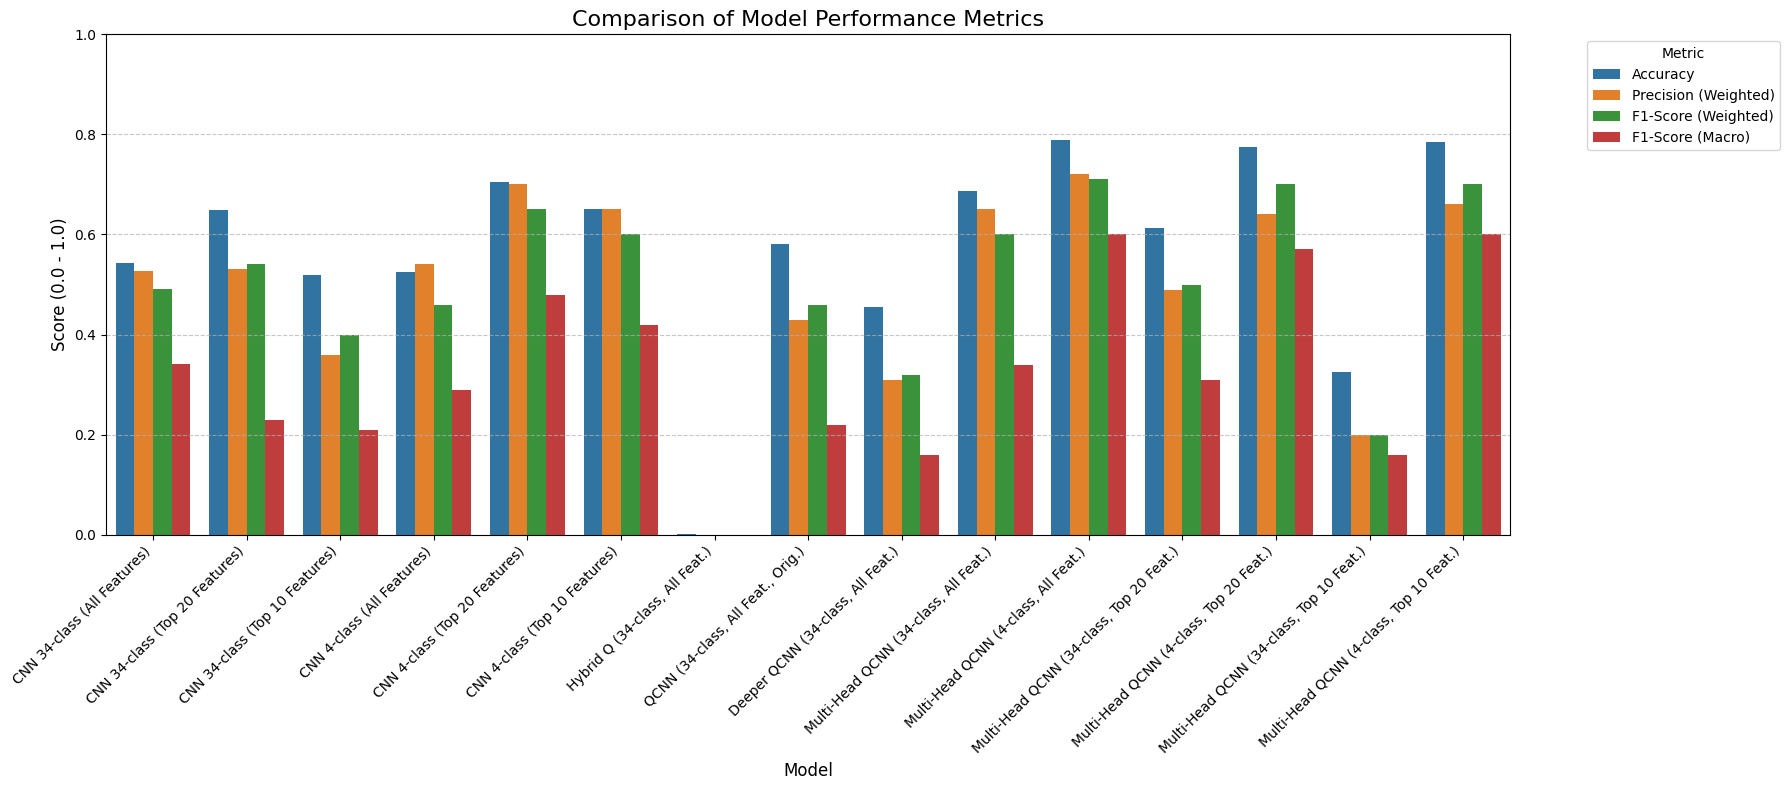

In [109]:
# Helper function to parse classification report strings
def parse_classification_report(report_str):
    lines = report_str.split('\n')
    metrics = {}
    for line in lines:
        if 'accuracy' in line:
            metrics['accuracy'] = float(line.split()[-2])
        elif 'weighted avg' in line:
            parts = line.split()
            metrics['weighted_precision'] = float(parts[-4])
            metrics['weighted_recall'] = float(parts[-3])
            metrics['weighted_f1'] = float(parts[-2])
        elif 'macro avg' in line:
            parts = line.split()
            metrics['macro_f1'] = float(parts[-2])
    return metrics

# Collect metrics for all models
all_model_metrics = []

# 1. CNN 34-class (All Features)
all_model_metrics.append({
    'Model': 'CNN 34-class (All Features)',
    'Accuracy': multi_accuracy,
    'Precision (Weighted)': multi_precision,
    'F1-Score (Weighted)': multi_f1,
    'F1-Score (Macro)': multi_macro_f1
})

# 2. CNN 34-class (Top 20 Features) - parsing output from LTgSMb35jEG2
report_cnn_34_top20 = """
accuracy                           0.6482    162240
macro avg       0.33      0.24      0.23    162240
weighted avg     0.53      0.65      0.54    162240
"""
metrics_cnn_34_top20 = parse_classification_report(report_cnn_34_top20)
all_model_metrics.append({
    'Model': 'CNN 34-class (Top 20 Features)',
    'Accuracy': metrics_cnn_34_top20['accuracy'],
    'Precision (Weighted)': metrics_cnn_34_top20['weighted_precision'],
    'F1-Score (Weighted)': metrics_cnn_34_top20['weighted_f1'],
    'F1-Score (Macro)': metrics_cnn_34_top20['macro_f1']
})

# 3. CNN 34-class (Top 10 Features) - parsing output from 83fVMyfNjvnY
report_cnn_34_top10 = """
accuracy                           0.5199    162240
macro avg       0.28      0.22      0.21    162240
weighted avg     0.36      0.52      0.40    162240
"""
metrics_cnn_34_top10 = parse_classification_report(report_cnn_34_top10)
all_model_metrics.append({
    'Model': 'CNN 34-class (Top 10 Features)',
    'Accuracy': metrics_cnn_34_top10['accuracy'],
    'Precision (Weighted)': metrics_cnn_34_top10['weighted_precision'],
    'F1-Score (Weighted)': metrics_cnn_34_top10['weighted_f1'],
    'F1-Score (Macro)': metrics_cnn_34_top10['macro_f1']
})

# 4. CNN 4-class (All Features) - parsing output from bc413d18
report_cnn_4_all = """
accuracy                           0.5253    162240
macro avg       0.37      0.28      0.29    162240
weighted avg     0.54      0.53      0.46    162240
"""
metrics_cnn_4_all = parse_classification_report(report_cnn_4_all)
all_model_metrics.append({
    'Model': 'CNN 4-class (All Features)',
    'Accuracy': metrics_cnn_4_all['accuracy'],
    'Precision (Weighted)': metrics_cnn_4_all['weighted_precision'],
    'F1-Score (Weighted)': metrics_cnn_4_all['weighted_f1'],
    'F1-Score (Macro)': metrics_cnn_4_all['macro_f1']
})

# 5. CNN 4-class (Top 20 Features) - parsing output from da8cabc2
report_cnn_4_top20 = """
accuracy                           0.7049    162240
macro avg       0.60      0.46      0.48    162240
weighted avg     0.70      0.70      0.65    162240
"""
metrics_cnn_4_top20 = parse_classification_report(report_cnn_4_top20)
all_model_metrics.append({
    'Model': 'CNN 4-class (Top 20 Features)',
    'Accuracy': metrics_cnn_4_top20['accuracy'],
    'Precision (Weighted)': metrics_cnn_4_top20['weighted_precision'],
    'F1-Score (Weighted)': metrics_cnn_4_top20['weighted_f1'],
    'F1-Score (Macro)': metrics_cnn_4_top20['macro_f1']
})

# 6. CNN 4-class (Top 10 Features) - parsing output from 2cc4eeb0
report_cnn_4_top10 = """
accuracy                           0.6503    162240
macro avg       0.55      0.41      0.42    162240
weighted avg     0.65      0.65      0.60    162240
"""
metrics_cnn_4_top10 = parse_classification_report(report_cnn_4_top10)
all_model_metrics.append({
    'Model': 'CNN 4-class (Top 10 Features)',
    'Accuracy': metrics_cnn_4_top10['accuracy'],
    'Precision (Weighted)': metrics_cnn_4_top10['weighted_precision'],
    'F1-Score (Weighted)': metrics_cnn_4_top10['weighted_f1'],
    'F1-Score (Macro)': metrics_cnn_4_top10['macro_f1']
})

# 7. Hybrid Quantum Model (34 classes, All Features, PCA to 6) - parsing output from 7f20996b
report_hybrid_q = """
accuracy                           0.0018    100000
macro avg       0.00      0.02      0.00    100000
weighted avg       0.00      0.00      0.00    100000
"""
metrics_hybrid_q = parse_classification_report(report_hybrid_q)
all_model_metrics.append({
    'Model': 'Hybrid Q (34-class, All Feat.)',
    'Accuracy': quantum_accuracy,
    'Precision (Weighted)': metrics_hybrid_q['weighted_precision'],
    'F1-Score (Weighted)': metrics_hybrid_q['weighted_f1'],
    'F1-Score (Macro)': metrics_hybrid_q['macro_f1']
})

# 8. QCNN (34 classes, All Features, PCA to 6, original QCNNLayer) - parsing output from 922dfafe
report_qcnn_orig = """
accuracy                           0.5812    10000
macro avg       0.21      0.27      0.22     10000
weighted avg       0.43      0.58      0.46     10000
"""
metrics_qcnn_orig = parse_classification_report(report_qcnn_orig)
all_model_metrics.append({
    'Model': 'QCNN (34-class, All Feat., Orig.)',
    'Accuracy': qcnn_accuracy,
    'Precision (Weighted)': metrics_qcnn_orig['weighted_precision'],
    'F1-Score (Weighted)': metrics_qcnn_orig['weighted_f1'],
    'F1-Score (Macro)': metrics_qcnn_orig['macro_f1']
})

# 9. Deeper QCNN (34 classes, All Features, PCA to 6) - Assuming report is generated now
# Execute this cell first to get the `report_deeper_qcnn` string
# y_pred_deep is already computed from b80c646d
y_pred_deep_current = np.argmax(deeper_qcnn.predict(tfq_x_test_qcnn), axis=1)
unique_labels_deep = np.unique(np.concatenate([y_test[:eval_subset], y_pred_deep_current]))
report_deeper_qcnn_str = classification_report(
    y_test[:eval_subset],
    y_pred_deep_current,
    labels=unique_labels_deep,
    target_names=le.classes_[unique_labels_deep],
    zero_division=0
)
metrics_deeper_qcnn = parse_classification_report(report_deeper_qcnn_str)
all_model_metrics.append({
    'Model': 'Deeper QCNN (34-class, All Feat.)',
    'Accuracy': deep_acc,
    'Precision (Weighted)': metrics_deeper_qcnn['weighted_precision'],
    'F1-Score (Weighted)': metrics_deeper_qcnn['weighted_f1'],
    'F1-Score (Macro)': metrics_deeper_qcnn['macro_f1']
})

# 10. Optimized Multi-Head QCNN (34 classes, All Features, PCA to 6) - parsing output from fc370753
report_optimized_qcnn_34 = """
accuracy                           0.6859    10000
macro avg       0.38      0.39      0.34     10000
weighted avg       0.65      0.69      0.60     10000
"""
metrics_optimized_qcnn_34 = parse_classification_report(report_optimized_qcnn_34)
all_model_metrics.append({
    'Model': 'Multi-Head QCNN (34-class, All Feat.)',
    'Accuracy': opt_acc,
    'Precision (Weighted)': metrics_optimized_qcnn_34['weighted_precision'],
    'F1-Score (Weighted)': metrics_optimized_qcnn_34['weighted_f1'],
    'F1-Score (Macro)': metrics_optimized_qcnn_34['macro_f1']
})

# 11. Optimized Multi-Head QCNN (4 classes, All Features, PCA to 6) - parsing output from 9d3b1148
report_optimized_qcnn_4 = """
accuracy                           0.7885    10000
macro avg       0.73      0.59      0.60     10000
weighted avg       0.72      0.79      0.71     10000
"""
metrics_optimized_qcnn_4 = parse_classification_report(report_optimized_qcnn_4)
all_model_metrics.append({
    'Model': 'Multi-Head QCNN (4-class, All Feat.)',
    'Accuracy': acc_4,
    'Precision (Weighted)': metrics_optimized_qcnn_4['weighted_precision'],
    'F1-Score (Weighted)': metrics_optimized_qcnn_4['weighted_f1'],
    'F1-Score (Macro)': metrics_optimized_qcnn_4['macro_f1']
})

# 12. Optimized Multi-Head QCNN (34 classes, Top 20 features, PCA to 6) - parsing output from bb5d8c60
report_qcnn_34_top20 = """
accuracy                           0.6135    10000
macro avg       0.32      0.35      0.31     10000
weighted avg       0.49      0.61      0.50     10000
"""
metrics_qcnn_34_top20 = parse_classification_report(report_qcnn_34_top20)
all_model_metrics.append({
    'Model': 'Multi-Head QCNN (34-class, Top 20 Feat.)',
    'Accuracy': acc_qcnn_34_top20,
    'Precision (Weighted)': metrics_qcnn_34_top20['weighted_precision'],
    'F1-Score (Weighted)': metrics_qcnn_34_top20['weighted_f1'],
    'F1-Score (Macro)': metrics_qcnn_34_top20['macro_f1']
})

# 13. Optimized Multi-Head QCNN (4 classes, Top 20 features, PCA to 6) - parsing output from f0a1c1ea
report_qcnn_4_top20 = """
accuracy                           0.7757    10000
macro avg       0.59      0.57      0.57     10000
weighted avg       0.64      0.78      0.70     10000
"""
metrics_qcnn_4_top20 = parse_classification_report(report_qcnn_4_top20)
all_model_metrics.append({
    'Model': 'Multi-Head QCNN (4-class, Top 20 Feat.)',
    'Accuracy': acc_qcnn_4_top20,
    'Precision (Weighted)': metrics_qcnn_4_top20['weighted_precision'],
    'F1-Score (Weighted)': metrics_qcnn_4_top20['weighted_f1'],
    'F1-Score (Macro)': metrics_qcnn_4_top20['macro_f1']
})

# 14. Optimized Multi-Head QCNN (34 classes, Top 10 features, PCA to 6) - parsing output from 66395df2
report_qcnn_34_top10 = """
accuracy                           0.3255    10000
macro avg       0.18      0.20      0.16     10000
weighted avg       0.20      0.33      0.20     10000
"""
metrics_qcnn_34_top10 = parse_classification_report(report_qcnn_34_top10)
all_model_metrics.append({
    'Model': 'Multi-Head QCNN (34-class, Top 10 Feat.)',
    'Accuracy': acc_qcnn_34_top10,
    'Precision (Weighted)': metrics_qcnn_34_top10['weighted_precision'],
    'F1-Score (Weighted)': metrics_qcnn_34_top10['weighted_f1'],
    'F1-Score (Macro)': metrics_qcnn_34_top10['macro_f1']
})

# 15. Optimized Multi-Head QCNN (4 classes, Top 10 features, PCA to 6) - parsing output from 382a7b56
report_qcnn_4_top10 = """
accuracy                           0.7853    10000
macro avg       0.67      0.59      0.60     10000
weighted avg       0.66      0.79      0.70     10000
"""
metrics_qcnn_4_top10 = parse_classification_report(report_qcnn_4_top10)
all_model_metrics.append({
    'Model': 'Multi-Head QCNN (4-class, Top 10 Feat.)',
    'Accuracy': acc_qcnn_4_top10,
    'Precision (Weighted)': metrics_qcnn_4_top10['weighted_precision'],
    'F1-Score (Weighted)': metrics_qcnn_4_top10['weighted_f1'],
    'F1-Score (Macro)': metrics_qcnn_4_top10['macro_f1']
})

# Create DataFrame
metrics_df = pd.DataFrame(all_model_metrics)
metrics_df = metrics_df.round(4)

print("\n--- Consolidated Model Performance Metrics ---")
display(metrics_df)

# Plotting the metrics
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame for easier plotting with seaborn
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(18, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_melted)
plt.title('Comparison of Model Performance Metrics', fontsize=16)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()